In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

c:\Users\bgven28524\AppData\Local\Continuum\anaconda3\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


#  # Reading the Data

In [5]:
import os
os.chdir('C:\\Users\\bgven28524\\Downloads')

# Load Historical Trader Data
trader_df = pd.read_csv("historical_data.csv")

# Load Bitcoin Fear & Greed Sentiment Data
sentiment_df = pd.read_csv("fear_greed_index.csv")

In [6]:
print("Trader Data Shape:", trader_df.shape)
print("Sentiment Data Shape:", sentiment_df.shape)

Trader Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


In [7]:
print("Trader Data Columns:")
print(trader_df.columns)

print("Sentiment Data Columns:")
print(sentiment_df.columns)

Trader Data Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Sentiment Data Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [8]:
print("Trader Data Sample:")
display(trader_df.head())

Trader Data Sample:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
print("Sentiment Data Sample:")
display(sentiment_df.head())

Sentiment Data Sample:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [10]:
print("Trader Data Info:")
trader_df.info()

Trader Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes:

In [11]:
print("Sentiment Data Info:")
sentiment_df.info()

Sentiment Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [12]:
trader_df.columns = (
    trader_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

sentiment_df.columns = (
    sentiment_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Clean Trader Columns:")
print(trader_df.columns)

print("Clean Sentiment Columns:")
print(sentiment_df.columns)

Clean Trader Columns:
Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')
Clean Sentiment Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [13]:
trader_df.rename(columns={
    "account": "account",
    "coin": "symbol",
    "execution_price": "execution_price",
    "size_tokens": "size_tokens",
    "size_usd": "size_usd",
    "side": "side",
    "timestamp_ist": "timestamp_ist",
    "start_position": "start_position",
    "direction": "direction",
    "closed_pnl": "closed_pnl",
    "fee": "fee",
    "trade_id": "trade_id",
    "timestamp": "timestamp"
}, inplace=True)

In [14]:
sentiment_df.rename(columns={
    "date": "sentiment_date",
    "classification": "classification",
    "value": "sentiment_value",
    "timestamp": "sentiment_timestamp"
}, inplace=True)

# Check Missing Values

In [15]:
trader_missing = trader_df.isnull().sum().sort_values(ascending=False)
print("Missing Values in Trader Data:")
print(trader_missing)

Missing Values in Trader Data:
account             0
symbol              0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
dtype: int64


In [16]:
sentiment_missing = sentiment_df.isnull().sum().sort_values(ascending=False)
print("Missing Values in Sentiment Data:")
print(sentiment_missing)

Missing Values in Sentiment Data:
sentiment_timestamp    0
sentiment_value        0
classification         0
sentiment_date         0
dtype: int64


# Check Duplicate Records

In [17]:
print("Duplicate Rows in Trader Data:", trader_df.duplicated().sum())
print("Duplicate Rows in Sentiment Data:", sentiment_df.duplicated().sum())

Duplicate Rows in Trader Data: 0
Duplicate Rows in Sentiment Data: 0


In [18]:
print("Duplicate Rows in Trader Data:", trader_df.duplicated().sum())
print("Duplicate Rows in Sentiment Data:", sentiment_df.duplicated().sum())

Duplicate Rows in Trader Data: 0
Duplicate Rows in Sentiment Data: 0


# Convert Date Columns

In [19]:
trader_df["timestamp_ist"] = pd.to_datetime(
    trader_df["timestamp_ist"],
    dayfirst=True,
    errors="coerce"
)

sentiment_df["sentiment_date"] = pd.to_datetime(
    sentiment_df["sentiment_date"],
    dayfirst=True,
    errors="coerce"
)

# Common Date Key for Joining

In [20]:
trader_df["trade_date"] = trader_df["timestamp_ist"].dt.date
sentiment_df["join_date"] = sentiment_df["sentiment_date"].dt.date

In [21]:
print(trader_df[["timestamp_ist", "trade_date"]].head())
print(sentiment_df[["sentiment_date", "join_date", "classification"]].head())

        timestamp_ist  trade_date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
  sentiment_date   join_date classification
0     2018-02-01  2018-02-01           Fear
1     2018-02-02  2018-02-02   Extreme Fear
2     2018-02-03  2018-02-03           Fear
3     2018-02-04  2018-02-04   Extreme Fear
4     2018-02-05  2018-02-05   Extreme Fear


# Join Trader Data with Sentiment Data

In [22]:
final_df = trader_df.merge(
    sentiment_df[["join_date", "sentiment_value", "classification"]],
    left_on="trade_date",
    right_on="join_date",
    how="left")

In [23]:
final_df.drop(columns=["join_date"], inplace=True)

In [24]:
print("Final Joined Data Shape:", final_df.shape)
display(final_df.head())

Final Joined Data Shape: (211224, 19)


,account,symbol,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_date,sentiment_value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [25]:
missing_sentiment = final_df["classification"].isnull().sum()
total_rows = len(final_df)

missing_sentiment_percentage = (missing_sentiment / total_rows) * 100

print("Missing Sentiment Rows:", missing_sentiment)
print("Missing Sentiment Percentage:", round(missing_sentiment_percentage, 2), "%")

Missing Sentiment Rows: 6
Missing Sentiment Percentage: 0.0 %


In [26]:
print("Trader Date Range:")
print(final_df["trade_date"].min(), "to", final_df["trade_date"].max())

print("Sentiment Date Range:")
print(sentiment_df["join_date"].min(), "to", sentiment_df["join_date"].max())

Trader Date Range:
2023-05-01 to 2025-05-01
Sentiment Date Range:
2018-02-01 to 2025-05-02


In [27]:
numeric_cols = [
    "execution_price",
    "size_tokens",
    "size_usd",
    "start_position",
    "closed_pnl",
    "fee",
    "sentiment_value"
]

In [28]:
for col in numeric_cols:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

In [29]:
pd.set_option("display.float_format", "{:.2f}".format)
final_df[numeric_cols].describe()

,execution_price,size_tokens,size_usd,start_position,closed_pnl,fee,sentiment_value
count,211224.00,211224.00,211224.00,211224.00,211224.00,211224.00,211218.00
mean,11414.72,4623.36,5639.45,-29946.25,48.75,1.16,51.65
std,29447.65,104272.89,36575.14,673807.42,919.16,6.76,21.01
min,0.00,0.00,0.00,-14334629.00,-117990.10,-1.18,10.00
25%,4.85,2.94,193.79,-376.23,0.00,0.02,33.00
50%,18.28,32.00,597.05,84.73,0.00,0.09,49.00
75%,101.58,187.90,2058.96,9337.28,5.79,0.39,72.00
max,109004.00,15822438.00,3921430.72,30509482.00,135329.09,837.47,94.00


# Data Quality Checks

In [30]:
print("Total Records:", len(final_df))
print("Unique Accounts:", final_df["account"].nunique())
print("Unique Symbols:", final_df["symbol"].nunique())
print("Unique Trade Dates:", final_df["trade_date"].nunique())

Total Records: 211224
Unique Accounts: 32
Unique Symbols: 246
Unique Trade Dates: 480


In [31]:
print("Sentiment Distribution:")
print(final_df["classification"].value_counts(dropna=False))

Sentiment Distribution:
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: classification, dtype: int64


In [32]:
print("Side Distribution:")
print(final_df["side"].value_counts(dropna=False))

Side Distribution:
SELL    108528
BUY     102696
Name: side, dtype: int64


# Profit / Loss Flags

In [33]:
final_df["is_profit"] = np.where(final_df["closed_pnl"] > 0, 1, 0)
final_df["is_loss"] = np.where(final_df["closed_pnl"] < 0, 1, 0)
final_df["is_zero_pnl"] = np.where(final_df["closed_pnl"] == 0, 1, 0)

# Net PnL After Fee

In [34]:
final_df["net_pnl"] = final_df["closed_pnl"] - final_df["fee"]
final_df[["closed_pnl", "fee", "net_pnl"]].head()

,closed_pnl,fee,net_pnl
0,0.00,0.35,-0.35
1,0.00,0.01,-0.01
2,0.00,0.05,-0.05
3,0.00,0.05,-0.05
4,0.00,0.00,-0.00


# Trade Size Buckets

In [35]:
final_df["trade_size_bucket"] = pd.qcut(
    final_df["size_usd"],
    q=4,
    labels=["Small", "Medium", "Large", "Very Large"],
    duplicates="drop"
)

In [36]:
final_df[["size_usd", "trade_size_bucket"]].head()

,size_usd,trade_size_bucket
0,7872.16,Very Large
1,127.68,Small
2,1150.63,Large
3,1142.04,Large
4,69.75,Small


# Time Features

In [37]:
final_df["trade_date_datetime"] = pd.to_datetime(final_df["trade_date"])

final_df["trade_year"] = final_df["trade_date_datetime"].dt.year
final_df["trade_month"] = final_df["trade_date_datetime"].dt.month
final_df["trade_week"] = final_df["trade_date_datetime"].dt.isocalendar().week
final_df["trade_day"] = final_df["trade_date_datetime"].dt.day
final_df["trade_day_name"] = final_df["trade_date_datetime"].dt.day_name()
final_df[["trade_date", "trade_month", "trade_week", "trade_day_name"]].head()

,trade_date,trade_month,trade_week,trade_day_name
0,2024-12-02,12,49,Monday
1,2024-12-02,12,49,Monday
2,2024-12-02,12,49,Monday
3,2024-12-02,12,49,Monday
4,2024-12-02,12,49,Monday


In [ ]:
# 

# Sentiment-Wise Performance

In [41]:
sentiment_summary = final_df.groupby("classification").agg(
    total_trades=("trade_id", "count"),
    unique_accounts=("account", "nunique"),
    unique_symbols=("symbol", "nunique"),
    total_pnl=("closed_pnl", "sum"),
    total_net_pnl=("net_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    median_pnl=("closed_pnl", "median"),
    max_profit=("closed_pnl", "max"),
    max_loss=("closed_pnl", "min"),
    total_volume_usd=("size_usd", "sum"),
    avg_trade_size_usd=("size_usd", "mean"),
    profit_trades=("is_profit", "sum"),
    loss_trades=("is_loss", "sum"),
    zero_pnl_trades=("is_zero_pnl", "sum")
).reset_index()


sentiment_summary["win_rate_%"] = (
    sentiment_summary["profit_trades"] / sentiment_summary["total_trades"]
) * 100

sentiment_summary["loss_rate_%"] = (
    sentiment_summary["loss_trades"] / sentiment_summary["total_trades"]
) * 100

sentiment_summary["avg_pnl_per_1000_usd_volume"] = (
    sentiment_summary["total_pnl"] / sentiment_summary["total_volume_usd"]
) * 1000

display(sentiment_summary.round(2))

,classification,total_trades,unique_accounts,unique_symbols,total_pnl,total_net_pnl,avg_pnl,median_pnl,max_profit,max_loss,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,zero_pnl_trades,win_rate_%,loss_rate_%,avg_pnl_per_1000_usd_volume
0,Extreme Fear,21400,32,85,739110.25,715221.61,34.54,0.00,115287.00,-31036.69,114484261.44,5349.73,7931,2475,10994,37.06,11.57,6.46
1,Extreme Greed,39992,30,165,2715171.31,2688140.65,67.89,0.00,44223.45,-10259.47,124465164.57,3112.25,18594,2259,19139,46.49,5.65,21.81
2,Fear,61837,32,134,3357155.44,3264698.49,54.29,0.00,135329.09,-35681.75,483324789.79,7816.11,26019,3789,32029,42.08,6.13,6.95
3,Greed,50303,31,193,2150129.27,2087030.58,42.74,0.00,74530.52,-117990.10,288582494.72,5736.88,19358,5818,25127,38.48,11.57,7.45
4,Neutral,37686,31,147,1292920.68,1253546.41,34.31,0.00,48504.10,-24500.00,180242063.08,4782.73,14961,3198,19527,39.70,8.49,7.17


In [42]:
sentiment_summary.to_csv('sentiment_summary.csv',index = False)


PermissionError: [Errno 13] Permission denied: 'sentiment_summary.csv'

# Fear vs Greed Interpretation

In [43]:
fear_data = sentiment_summary[sentiment_summary["classification"] == "Fear"]
greed_data = sentiment_summary[sentiment_summary["classification"] == "Greed"]
display(fear_data)
display(greed_data)

,classification,total_trades,unique_accounts,unique_symbols,total_pnl,total_net_pnl,avg_pnl,median_pnl,max_profit,max_loss,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,zero_pnl_trades,win_rate_%,loss_rate_%,avg_pnl_per_1000_usd_volume
2,Fear,61837,32,134,3357155.44,3264698.49,54.29,0.00,135329.09,-35681.75,483324789.79,7816.11,26019,3789,32029,42.08,6.13,6.95


,classification,total_trades,unique_accounts,unique_symbols,total_pnl,total_net_pnl,avg_pnl,median_pnl,max_profit,max_loss,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,zero_pnl_trades,win_rate_%,loss_rate_%,avg_pnl_per_1000_usd_volume
3,Greed,50303,31,193,2150129.27,2087030.58,42.74,0.00,74530.52,-117990.10,288582494.72,5736.88,19358,5818,25127,38.48,11.57,7.45


# Account-Level Performance by Sentiment

In [131]:
account_sentiment_summary = final_df.groupby(
    ["account", "classification"]
).agg(
    total_trades=("trade_id", "count"),
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    total_volume_usd=("size_usd", "sum"),
    avg_trade_size_usd=("size_usd", "mean"),
    profit_trades=("is_profit", "sum"),
    loss_trades=("is_loss", "sum")
).reset_index()


account_sentiment_summary["win_rate_%"] = (
    account_sentiment_summary["profit_trades"] /
    account_sentiment_summary["total_trades"]
) * 100


account_sentiment_summary = account_sentiment_summary.sort_values(
    by="total_pnl",
    ascending=False
)

display(account_sentiment_summary.head(20))

,account,classification,total_trades,total_pnl,avg_pnl,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,win_rate_%
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1778,1113373.55,626.19,30262439.89,17020.49,936,115,52.64
135,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,1643,1105304.86,672.74,5161529.02,3141.53,838,55,51.00
143,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Fear,12437,620872.38,49.92,40734967.95,3275.30,6197,86,49.83
137,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,5889,534058.24,90.69,36284991.08,6161.49,1609,855,27.32
152,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,6723,478811.47,71.22,16527882.25,2458.41,4009,511,59.63
78,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,Greed,593,453595.32,764.92,5049640.49,8515.41,188,81,31.70
138,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Neutral,3457,401309.43,116.09,9064146.19,2621.97,1307,228,37.81
69,0x513b8629fe877bb581bf244e326a047b249c4ff1,Neutral,2517,381330.49,151.50,69726062.55,27702.05,1395,48,55.42
67,0x513b8629fe877bb581bf244e326a047b249c4ff1,Fear,5981,367166.22,61.39,225087033.36,37633.68,2216,360,37.05
57,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,Fear,1396,296781.72,212.59,18227807.74,13057.17,571,28,40.90


# Top Profitable Accounts

In [132]:
top_accounts = account_sentiment_summary[
    account_sentiment_summary["total_trades"] >= 5
].sort_values(
    by="total_pnl",
    ascending=False
)

display(top_accounts.head(10))

,account,classification,total_trades,total_pnl,avg_pnl,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,win_rate_%
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1778,1113373.55,626.19,30262439.89,17020.49,936,115,52.64
135,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,1643,1105304.86,672.74,5161529.02,3141.53,838,55,51.00
143,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Fear,12437,620872.38,49.92,40734967.95,3275.30,6197,86,49.83
137,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,5889,534058.24,90.69,36284991.08,6161.49,1609,855,27.32
152,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,6723,478811.47,71.22,16527882.25,2458.41,4009,511,59.63
78,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,Greed,593,453595.32,764.92,5049640.49,8515.41,188,81,31.70
138,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Neutral,3457,401309.43,116.09,9064146.19,2621.97,1307,228,37.81
69,0x513b8629fe877bb581bf244e326a047b249c4ff1,Neutral,2517,381330.49,151.50,69726062.55,27702.05,1395,48,55.42
67,0x513b8629fe877bb581bf244e326a047b249c4ff1,Fear,5981,367166.22,61.39,225087033.36,37633.68,2216,360,37.05
57,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,Fear,1396,296781.72,212.59,18227807.74,13057.17,571,28,40.90


# Symbol-Level Performance by Sentiment

In [133]:
symbol_sentiment_summary = final_df.groupby(
    ["symbol", "classification"]
).agg(
    total_trades=("trade_id", "count"),
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    total_volume_usd=("size_usd", "sum"),
    avg_trade_size_usd=("size_usd", "mean"),
    profit_trades=("is_profit", "sum"),
    loss_trades=("is_loss", "sum")
).reset_index()

symbol_sentiment_summary["win_rate_%"] = (
    symbol_sentiment_summary["profit_trades"] /
    symbol_sentiment_summary["total_trades"]
) * 100

symbol_sentiment_summary = symbol_sentiment_summary.sort_values(
    by="total_pnl",
    ascending=False
)

display(symbol_sentiment_summary.head(20))

,symbol,classification,total_trades,total_pnl,avg_pnl,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,win_rate_%
10,@107,Extreme Greed,10403,1988618.87,191.16,20452573.55,1966.03,5843,498,56.17
374,HYPE,Fear,27951,840306.35,30.06,63327528.27,2265.66,12140,1397,43.43
585,SOL,Fear,3914,741594.29,189.47,51824505.65,13240.80,1958,103,50.03
12,@107,Greed,8398,724342.31,86.25,16923981.98,2015.24,3854,1184,45.89
312,ETH,Fear,2850,675064.58,236.86,39635351.10,13907.14,1188,240,41.68
264,BTC,Fear,9870,482649.64,48.90,300912163.30,30487.55,3805,537,38.55
372,HYPE,Extreme Fear,10278,482083.81,46.90,29253178.69,2846.19,4079,682,39.69
586,SOL,Greed,1586,451690.01,284.80,22849528.78,14407.02,455,52,28.69
313,ETH,Greed,3574,351036.01,98.22,37325288.10,10443.56,927,630,25.94
587,SOL,Neutral,1400,303376.19,216.70,16118744.79,11513.39,730,80,52.14


# Buy / Sell Performance by Sentiment

In [134]:
side_sentiment_summary = final_df.groupby(
    ["side", "classification"]
).agg(
    total_trades=("trade_id", "count"),
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    total_volume_usd=("size_usd", "sum"),
    avg_trade_size_usd=("size_usd", "mean"),
    profit_trades=("is_profit", "sum"),
    loss_trades=("is_loss", "sum")
).reset_index()


side_sentiment_summary["win_rate_%"] = (
    side_sentiment_summary["profit_trades"] /
    side_sentiment_summary["total_trades"]
) * 100

display(side_sentiment_summary)

,side,classification,total_trades,total_pnl,avg_pnl,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,win_rate_%
0,BUY,Extreme Fear,10935,373043.44,34.11,56441029.67,5161.50,2205,918,20.16
1,BUY,Extreme Greed,17940,188350.75,10.50,60332842.01,3363.03,5587,913,31.14
2,BUY,Fear,30270,1935073.44,63.93,246841746.11,8154.67,7961,1269,26.30
3,BUY,Greed,24576,614456.58,25.00,154988320.20,6306.49,7817,3526,31.81
4,BUY,Neutral,18969,554415.09,29.23,73626474.65,3881.41,4553,1308,24.00
5,SELL,Extreme Fear,10465,366066.81,34.98,58043231.77,5546.41,5726,1557,54.72
6,SELL,Extreme Greed,22052,2526820.56,114.58,64132322.56,2908.23,13007,1346,58.98
7,SELL,Fear,31567,1422082.00,45.05,236483043.68,7491.46,18058,2520,57.21
8,SELL,Greed,25727,1535672.69,59.69,133594174.52,5192.76,11541,2292,44.86
9,SELL,Neutral,18717,738505.58,39.46,106615588.43,5696.19,10408,1890,55.61


# Trade Size Bucket Analysis

In [135]:
trade_size_summary = final_df.groupby(
    ["trade_size_bucket", "classification"]
).agg(
    total_trades=("trade_id", "count"),
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    total_volume_usd=("size_usd", "sum"),
    profit_trades=("is_profit", "sum"),
    loss_trades=("is_loss", "sum")
).reset_index()

trade_size_summary["win_rate_%"] = (
    trade_size_summary["profit_trades"] /
    trade_size_summary["total_trades"]
) * 100


display(trade_size_summary)

,trade_size_bucket,classification,total_trades,total_pnl,avg_pnl,total_volume_usd,profit_trades,loss_trades,win_rate_%
0,Small,Extreme Fear,4141,-2478.89,-0.60,296977.87,1263,524,30.50
1,Small,Extreme Greed,12988,66310.16,5.11,905162.54,6898,605,53.11
2,Small,Fear,13051,17782.61,1.36,897654.50,5355,780,41.03
3,Small,Greed,12894,26780.65,2.08,922153.31,5390,1508,41.80
4,Small,Neutral,9754,6095.33,0.62,635077.11,3868,880,39.66
5,Medium,Extreme Fear,5361,13474.62,2.51,2254967.82,1887,650,35.20
6,Medium,Extreme Greed,9209,147417.22,16.01,3522438.36,4088,563,44.39
7,Medium,Fear,15229,83485.42,5.48,6038417.33,6271,887,41.18
8,Medium,Greed,13013,66735.47,5.13,5157548.61,4190,2191,32.20
9,Medium,Neutral,9971,37076.14,3.72,3867053.62,3791,795,38.02


# Daily Performance Analysis

In [136]:
daily_summary = final_df.groupby(
    ["trade_date", "classification"]
).agg(
    total_trades=("trade_id", "count"),
    daily_pnl=("closed_pnl", "sum"),
    daily_net_pnl=("net_pnl", "sum"),
    daily_volume_usd=("size_usd", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    profit_trades=("is_profit", "sum"),
    loss_trades=("is_loss", "sum")
).reset_index()


daily_summary["win_rate_%"] = (
    daily_summary["profit_trades"] /
    daily_summary["total_trades"]
) * 100

display(daily_summary.head())

,trade_date,classification,total_trades,daily_pnl,daily_net_pnl,daily_volume_usd,avg_pnl,profit_trades,loss_trades,win_rate_%
0,2023-05-01,Greed,3,0.00,0.00,477.00,0.00,0,0,0.00
1,2023-12-05,Extreme Greed,9,0.00,-12.50,50005.83,0.00,0,0,0.00
2,2023-12-14,Greed,11,-205.43,-233.74,113203.35,-18.68,4,2,36.36
3,2023-12-15,Greed,2,-24.63,-27.28,10609.95,-12.32,0,2,0.00
4,2023-12-16,Greed,3,0.00,-3.84,15348.77,0.00,0,0,0.00


In [ ]:
# 

# Weekly Performance Analysis

In [137]:
weekly_summary = final_df.groupby(
    ["trade_year", "trade_week", "classification"]
).agg(
    total_trades=("trade_id", "count"),
    weekly_pnl=("closed_pnl", "sum"),
    weekly_net_pnl=("net_pnl", "sum"),
    weekly_volume_usd=("size_usd", "sum"),
    avg_pnl=("closed_pnl", "mean")
).reset_index()

display(weekly_summary.head())

,trade_year,trade_week,classification,total_trades,weekly_pnl,weekly_net_pnl,weekly_volume_usd,avg_pnl
0,2023,18,Greed,3,0.00,0.00,477.00,0.00
1,2023,49,Extreme Greed,9,0.00,-12.50,50005.83,0.00
2,2023,50,Greed,30,74.92,11.06,255440.09,2.50
3,2023,51,Greed,146,2997.87,2757.90,959904.82,20.53
4,2023,52,Greed,156,-1056.78,-1457.68,1603586.75,-6.77


# Total PnL by Sentiment

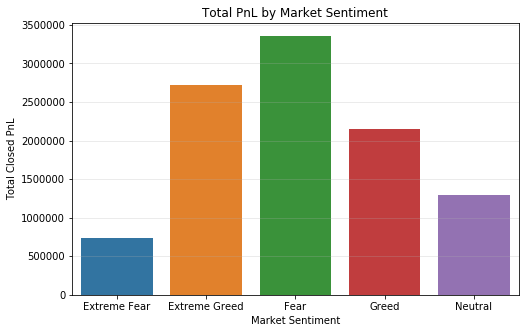

In [138]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=sentiment_summary,
    x="classification",
    y="total_pnl"
)

plt.title("Total PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Average PnL by Sentiment    

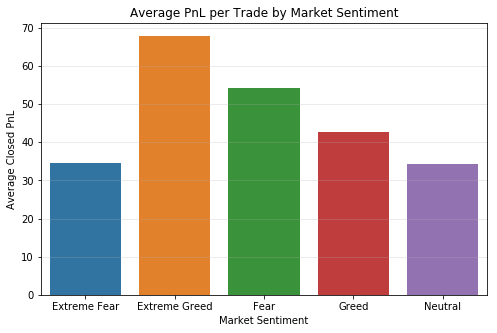

In [139]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=sentiment_summary,
    x="classification",
    y="avg_pnl"
)

plt.title("Average PnL per Trade by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Win Rate by Sentiment

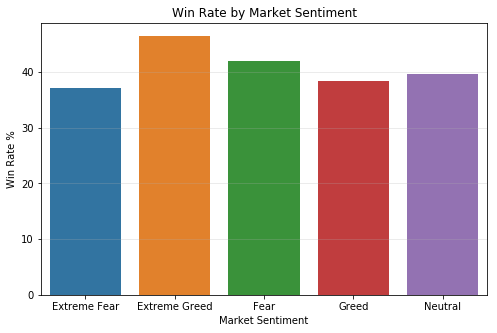

In [140]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=sentiment_summary,
    x="classification",
    y="win_rate_%"
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate %")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Number of Trades by Sentiment

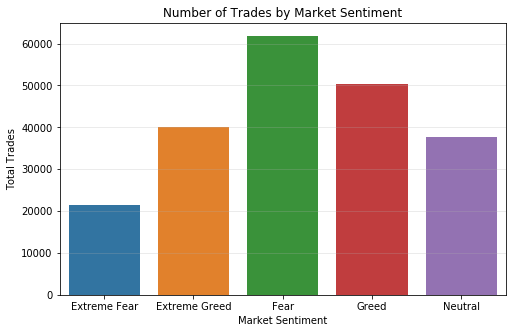

In [141]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=sentiment_summary,
    x="classification",
    y="total_trades"
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Trades")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Daily PnL Trend

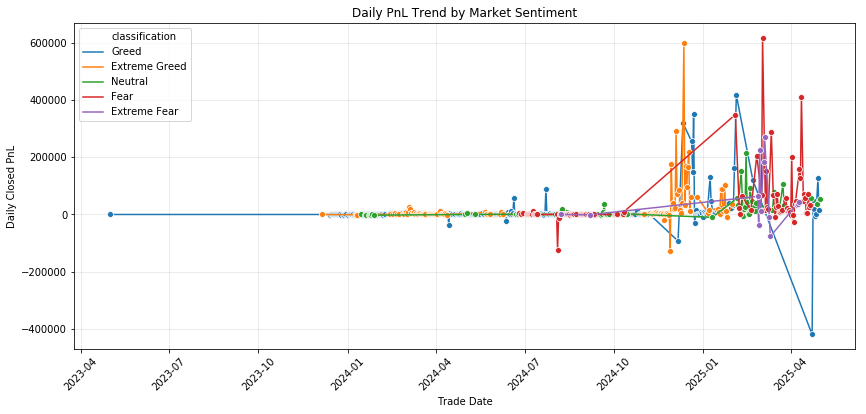

In [142]:
daily_summary["trade_date"] = pd.to_datetime(daily_summary["trade_date"])

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_summary,
    x="trade_date",
    y="daily_pnl",
    hue="classification",
    marker="o"
)

plt.title("Daily PnL Trend by Market Sentiment")
plt.xlabel("Trade Date")
plt.ylabel("Daily Closed PnL")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

# Side Performance

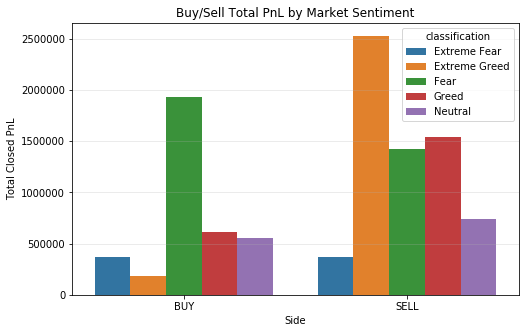

In [143]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=side_sentiment_summary,
    x="side",
    y="total_pnl",
    hue="classification"
)

plt.title("Buy/Sell Total PnL by Market Sentiment")
plt.xlabel("Side")
plt.ylabel("Total Closed PnL")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Trade Size Bucket Performance

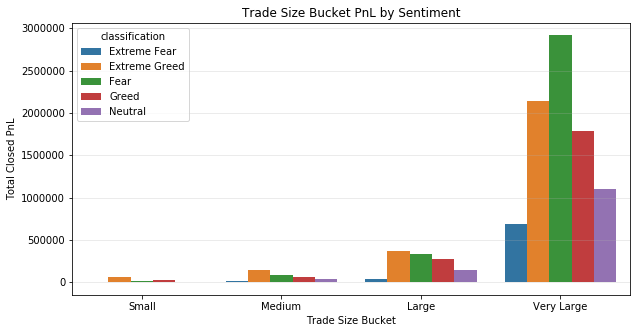

In [144]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=trade_size_summary,
    x="trade_size_bucket",
    y="total_pnl",
    hue="classification"
)

plt.title("Trade Size Bucket PnL by Sentiment")
plt.xlabel("Trade Size Bucket")
plt.ylabel("Total Closed PnL")
plt.grid(axis="y", alpha=0.3)

plt.show()


# Correlation Analysis

,closed_pnl,net_pnl,size_usd,fee,sentiment_value
closed_pnl,1.00,1.00,0.12,0.08,0.01
net_pnl,1.00,1.00,0.12,0.08,0.01
size_usd,0.12,0.12,1.00,0.75,-0.03
fee,0.08,0.08,0.75,1.00,-0.03
sentiment_value,0.01,0.01,-0.03,-0.03,1.00


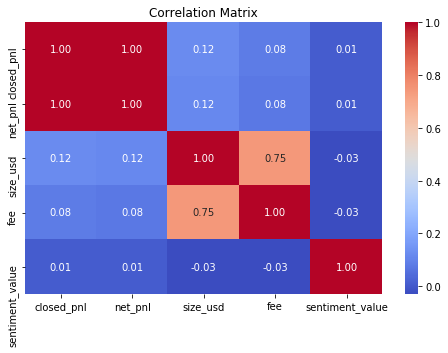

In [145]:
correlation_cols = [
    "closed_pnl",
    "net_pnl",
    "size_usd",
    "fee",
    "sentiment_value"
]

available_corr_cols = []

for col in correlation_cols:
    if col in final_df.columns:
        available_corr_cols.append(col)
        
corr_matrix = final_df[available_corr_cols].corr()
display(corr_matrix)    


plt.figure(figsize=(8, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()    

# High Volume but Loss Making Trades

In [146]:
high_volume_threshold = final_df["size_usd"].quantile(0.75)

high_volume_loss_trades = final_df[
    (final_df["size_usd"] >= high_volume_threshold) &
    (final_df["closed_pnl"] < 0)
]

print("High Volume Loss Trades:", len(high_volume_loss_trades))
display(high_volume_loss_trades.head())

high_volume_loss_summary = high_volume_loss_trades.groupby(
    "classification"
).agg(
    loss_trades=("trade_id", "count"),
    total_loss=("closed_pnl", "sum"),
    avg_loss=("closed_pnl", "mean"),
    avg_size_usd=("size_usd", "mean")
).reset_index()

display(high_volume_loss_summary)

High Volume Loss Trades: 4096


,account,symbol,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,is_loss,is_zero_pnl,net_pnl,trade_size_bucket,trade_date_datetime,trade_year,trade_month,trade_week,trade_day,trade_day_name
1665,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,S,0.52,13996.00,7291.92,BUY,2025-03-04 07:51:00,-123650.00,Close Short,-1298.83,...,1,0,-1299.53,Very Large,2025-03-04,2025,3,10,4,Tuesday
1671,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,S,0.52,8571.00,4465.49,BUY,2025-03-04 07:51:00,-104889.00,Close Short,-795.39,...,1,0,-795.82,Very Large,2025-03-04,2025,3,10,4,Tuesday
1724,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,S,0.52,4822.00,2512.26,BUY,2025-03-04 07:51:00,-37134.00,Close Short,-447.48,...,1,0,-447.72,Very Large,2025-03-04,2025,3,10,4,Tuesday
1773,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,S,0.52,4193.00,2184.55,BUY,2025-03-04 17:55:00,-16009.00,Close Short,-389.11,...,1,0,-389.32,Very Large,2025-03-04,2025,3,10,4,Tuesday
1776,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,S,0.52,6980.00,3636.58,BUY,2025-03-04 17:55:00,-6980.00,Close Short,-647.74,...,1,0,-648.09,Very Large,2025-03-04,2025,3,10,4,Tuesday


,classification,loss_trades,total_loss,avg_loss,avg_size_usd
0,Extreme Fear,608,-511491.19,-841.27,16421.33
1,Extreme Greed,558,-241504.40,-432.80,14125.72
2,Fear,1024,-528848.81,-516.45,29540.30
3,Greed,1178,-956264.13,-811.77,20335.91
4,Neutral,728,-346642.74,-476.16,14916.18


# Best Accounts During Fear

In [85]:
best_fear_accounts = account_sentiment_summary[
    account_sentiment_summary["classification"] == "Fear"
].sort_values(
    by="total_pnl",
    ascending=False
)

display(best_fear_accounts.head(10))

,account,classification,total_trades,total_pnl,avg_pnl,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,win_rate_%
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1778,1.113374e+06,626.194346,3.026244e+07,17020.494876,936,115,52.643420
143,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Fear,12437,6.208724e+05,49.921394,4.073497e+07,3275.304973,6197,86,49.827129
67,0x513b8629fe877bb581bf244e326a047b249c4ff1,Fear,5981,3.671662e+05,61.388767,2.250870e+08,37633.678876,2216,360,37.050660
57,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,Fear,1396,2.967817e+05,212.594357,1.822781e+07,13057.168868,571,28,40.902579
148,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,Fear,1181,2.367977e+05,200.506120,1.071279e+07,9070.947688,589,111,49.872989
97,0x8170715b3b381dffb7062c0298972d4727a0a63b,Fear,1745,1.512927e+05,86.700707,4.170375e+06,2389.899759,518,89,29.684814
82,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,Fear,431,1.445143e+05,335.300103,6.317479e+05,1465.772506,278,27,64.501160
42,0x420ab45e0bd8863569a5efbb9c05d91f40624641,Fear,98,9.964828e+04,1016.819167,6.174136e+05,6300.139082,35,0,35.714286
136,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Fear,3005,9.316516e+04,31.003381,4.792043e+06,1594.689694,983,6,32.712146
153,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Fear,12901,5.597880e+04,4.339105,1.939568e+07,1503.424356,4858,1579,37.655996


# Best Accounts During Greed

In [147]:
best_greed_accounts = account_sentiment_summary[
    account_sentiment_summary["classification"] == "Greed"
].sort_values(
    by="total_pnl",
    ascending=False
)

display(best_greed_accounts.head(10))

,account,classification,total_trades,total_pnl,avg_pnl,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,win_rate_%
137,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,5889,534058.24,90.69,36284991.08,6161.49,1609,855,27.32
78,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,Greed,593,453595.32,764.92,5049640.49,8515.41,188,81,31.70
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,574,276719.27,482.09,8686990.84,15134.13,92,61,16.03
154,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Greed,7338,243399.51,33.17,17601612.08,2398.69,3410,1014,46.47
48,0x430f09841d65beb3f27765503d0f850b8bce7713,Greed,772,227680.49,294.92,1174862.15,1521.84,492,0,63.73
68,0x513b8629fe877bb581bf244e326a047b249c4ff1,Greed,3169,163047.66,51.45,121999299.14,38497.73,1193,113,37.65
58,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,Greed,1135,96392.78,84.93,6357516.12,5601.34,676,45,59.56
88,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,Greed,2618,95937.39,36.65,6523818.28,2491.91,2115,125,80.79
63,0x4f93fead39b70a1824f981a54d4e55b278e9f760,Greed,2334,79023.47,33.86,34783947.19,14903.15,802,47,34.36
113,0x92f17e8d81a944691c10e753af1b1baae1a2cd0d,Greed,1199,60254.25,50.25,4734259.00,3948.51,405,14,33.78



# Best Symbols During Fear

In [148]:
best_fear_symbols = symbol_sentiment_summary[
    symbol_sentiment_summary["classification"] == "Fear"
].sort_values(
    by="total_pnl",
    ascending=False
)

display(best_fear_symbols.head(10))

,symbol,classification,total_trades,total_pnl,avg_pnl,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,win_rate_%
374,HYPE,Fear,27951,840306.35,30.06,63327528.27,2265.66,12140,1397,43.43
585,SOL,Fear,3914,741594.29,189.47,51824505.65,13240.80,1958,103,50.03
312,ETH,Fear,2850,675064.58,236.86,39635351.10,13907.14,1188,240,41.68
264,BTC,Fear,9870,482649.64,48.90,300912163.30,30487.55,3805,537,38.55
451,MELANIA,Fear,1985,196849.12,99.17,3477530.64,1751.90,592,3,29.82
303,ENA,Fear,193,160316.23,830.65,347628.23,1801.18,92,2,47.67
647,USUAL,Fear,94,45893.10,488.22,154681.70,1645.55,50,42,53.19
601,SUI,Fear,318,26130.15,82.17,1341882.96,4219.76,108,14,33.96
628,TRUMP,Fear,442,18920.46,42.81,1499406.49,3392.32,125,8,28.28
680,XRP,Fear,268,14977.16,55.88,1016981.93,3794.71,189,3,70.52


# Best Symbols During Greed

In [149]:
best_greed_symbols = symbol_sentiment_summary[
    symbol_sentiment_summary["classification"] == "Greed"
].sort_values(
    by="total_pnl",
    ascending=False
)

display(best_greed_symbols.head(10))

,symbol,classification,total_trades,total_pnl,avg_pnl,total_volume_usd,avg_trade_size_usd,profit_trades,loss_trades,win_rate_%
12,@107,Greed,8398,724342.31,86.25,16923981.98,2015.24,3854,1184,45.89
586,SOL,Greed,1586,451690.01,284.80,22849528.78,14407.02,455,52,28.69
313,ETH,Greed,3574,351036.01,98.22,37325288.10,10443.56,927,630,25.94
375,HYPE,Greed,6769,166307.64,24.57,11751723.20,1736.11,2515,255,37.15
703,ZRO,Greed,1152,143815.51,124.84,885934.05,769.04,383,337,33.25
265,BTC,Greed,7240,115475.19,15.95,164299783.90,22693.34,2405,804,33.22
602,SUI,Greed,880,101637.56,115.50,4158513.00,4725.58,295,10,33.52
236,BERA,Greed,412,83243.57,202.05,545933.81,1325.08,363,0,88.11
452,MELANIA,Greed,1231,73550.50,59.75,1468082.55,1192.59,850,167,69.05
409,JUP,Greed,288,43234.08,150.12,1112463.75,3862.72,152,8,52.78


# Final Business Interpretation

In [150]:
print("Final Business Interpretation")
print("--------------------------------")

best_sentiment_by_total_pnl = sentiment_summary.sort_values(
    by="total_pnl",
    ascending=False
).iloc[0]["classification"]

best_sentiment_by_avg_pnl = sentiment_summary.sort_values(
    by="avg_pnl",
    ascending=False
).iloc[0]["classification"]

best_sentiment_by_win_rate = sentiment_summary.sort_values(
    by="win_rate_%",
    ascending=False
).iloc[0]["classification"]

print("Best sentiment by Total PnL:", best_sentiment_by_total_pnl)
print("Best sentiment by Average PnL:", best_sentiment_by_avg_pnl)
print("Best sentiment by Win Rate:", best_sentiment_by_win_rate)

Final Business Interpretation
--------------------------------
Best sentiment by Total PnL: Fear
Best sentiment by Average PnL: Extreme Greed
Best sentiment by Win Rate: Extreme Greed


In [151]:
print("Final Business Interpretation")
print("--------------------------------")

best_sentiment_by_total_pnl = sentiment_summary.sort_values(
    by="total_pnl",
    ascending=False
).iloc[0]["classification"]

best_sentiment_by_avg_pnl = sentiment_summary.sort_values(
    by="avg_pnl",
    ascending=False
).iloc[0]["classification"]

best_sentiment_by_win_rate = sentiment_summary.sort_values(
    by="win_rate_%",
    ascending=False
).iloc[0]["classification"]

print("Best sentiment by Total PnL:", best_sentiment_by_total_pnl)
print("Best sentiment by Average PnL:", best_sentiment_by_avg_pnl)
print("Best sentiment by Win Rate:", best_sentiment_by_win_rate)

Final Business Interpretation
--------------------------------
Best sentiment by Total PnL: Fear
Best sentiment by Average PnL: Extreme Greed
Best sentiment by Win Rate: Extreme Greed
